# Fitting molecular energy constants

Energies of states are approximated by using polynomials, with fitted coefficients. These coefficients are historically fitted from experimental spectroscopic data. When one uses these coefficients from literature, it is important to consider the amount of transitions that were fitted, and the order of the fitted polynomial.

A common mistake of spectroscopists is using coefficients from multiple sources, or using coefficients for transitions that they were not determined for.

In this file, we demonstrate how to use a simple fitting algorithm to determine ones own coefficients using HITRAN data, which has a high amount of transitions.


# Theory

Different molecules have different formulations for their energy levels.

| Molecule | Polynomial                                                               |
| -------- | ------------------------------------------------------------------------ |
| H2       | $\Sigma_i c_i \left( J \cdot (J + 1) \right)^n$                          |
| NO       | $\Sigma_i c_i \left( (J-\frac{1}{2} ) \cdot (J + \frac{3}{2}) \right)^n$ |


# Methods

We use the HITRAN database as a map from the quantum numbers of state $i$ to the energy $E_i$ of state $i$, i.e. $\left| i \right \rangle \equiv \{J_i, v_i, ...\}\ \rightarrow\ E_i$.
In the case of e.g. H2, the set of quantum numbers $\{J_i,\ v_i\}$ completely defines the state $\left| i \right \rangle$. We define the set of quantum numbers as $\{q_{j}\}_i$

We're then solving the matrix equation of the form $Ax=b$ for $x$, or

$$
\begin{pmatrix}
f_1(q_1) & f_2(q_1) & \dots & f_n(q_1) \\
f_1(q_2) & f_2(q_2) & \dots & f_n(q_2) \\
\dots \\
f_1(q_3) & f_2(q_3) & \dots & f_n(q_3)
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
\dots \\
c_n
\end{pmatrix}
=
\begin{pmatrix}
E_1 \\
E_2 \\
\dots \\
E_n
\end{pmatrix}
$$


In [1]:
from ramlab.molecules import H2, CalculatedLinelistMolecule
from ramlab.molecules.custom_linelist_molecule import CustomLinelistMolecule
import numpy as np
import matplotlib.pyplot as plt
import wedme.apply.dev
from pathlib import Path

M_hitran = CustomLinelistMolecule(
    Path(
        "/Users/martijn/Projects/study/UM/ramlab/data/H2/HITRAN_linebyline_0_6000_cm-1.txt"
    )
)
M_abinitio = H2

transitions = M_hitran.get_all_transitions()
transitions_abinitio = M_abinitio.get_all_transitions()

print(transitions)
print(transitions_abinitio)

Transitions[1335](molec_id, trans_id, vacuum_wavenumber, a, statep, statepp, final_degeneracy, initial_degeneracy, sw, initial_E, nu-err, sw-err, nu-ref, sw-ref, final_v, initial_v, final_J, initial_J)
Transitions[492](initial_v, initial_J, initial_degeneracy, initial_E, final_v, final_J, final_degeneracy, final_E, dE, vacuum_wavenumber, molecule_number, isotope_number, dJ, dv, crosssection, depolarization_ratio)


# Check deviation between current implementation and HITRAN line list


Max error: 12250.924768230881
Std error: 3667.2003899839156


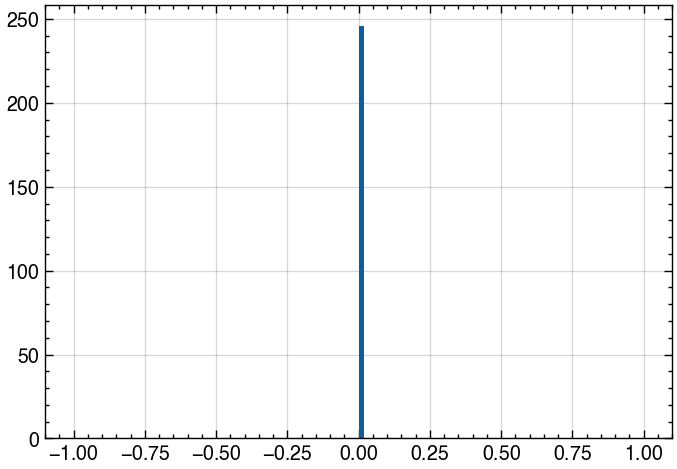

In [2]:
dE_hitran = M_hitran.dE(transitions_abinitio)
dE_ramlab = M_abinitio.dE(transitions_abinitio)
dE_diff = dE_hitran - dE_ramlab

dE_std = np.std(dE_diff)
dE_max = np.max(np.abs(dE_diff))
print(f"Max error: {dE_max}")
print(f"Std error: {dE_std}")

plt.figure()
plt.hist(dE_diff, bins=100, range=(-1, 1))
plt.show()

Max error: 1.228183773753699
Std error: 0.23026056316574933


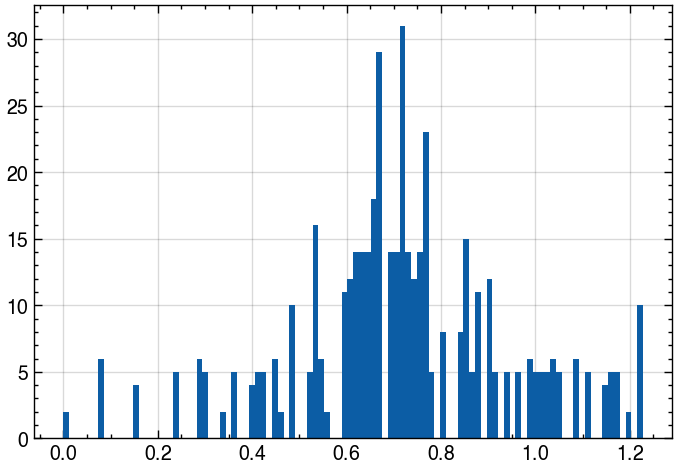

In [3]:
idx = (
    transitions.initial_E < 20e3
)  # Filter out high energy states. We have no desire to fit these accurately.
state_final = transitions.state_final[idx]
state_initial = transitions.state_initial[idx]


E_hitran = state_initial.E
E_ramlab = M_abinitio.E(state_initial)
E_ramlab -= np.min(E_ramlab)
dE = E_hitran - E_ramlab

idx_i = np.argmax(E_ramlab)

dE_std = np.std(dE)
dE_max = np.max(np.abs(dE))
print(f"Max error: {dE_max}")
print(f"Std error: {dE_std}")

plt.figure()
plt.hist(E_hitran - E_ramlab, bins=100)
plt.show()

E_vib = (-1) ** (2) * c_v_1 * (v + 1/2)**1 \
	+ (-1) ** (3) * c_v_2 * (v + 1/2)**2 \
	+ (-1) ** (4) * c_v_3 * (v + 1/2)**3
E_rot = (
		c_B_0 * (v + 1/2)**0 +
		c_B_1 * (v + 1/2)**1 +
		c_B_2 * (v + 1/2)**2 +
		c_B_3 * (v + 1/2)**3 +
		c_B_4 * (v + 1/2)**4
	) * (J * (J + 1))**1 \
	+(
		c_B_0 * (v + 1/2)**0 +
		c_B_1 * (v + 1/2)**1 +
		c_B_2 * (v + 1/2)**2 +
		c_B_3 * (v + 1/2)**3 +
		c_B_4 * (v + 1/2)**4
	) * (J * (J + 1))**2 \
	+(
		c_B_0 * (v + 1/2)**0 +
		c_B_1 * (v + 1/2)**1 +
		c_B_2 * (v + 1/2)**2 +
		c_B_3 * (v + 1/2)**3 +
		c_B_4 * (v + 1/2)**4
	) * (J * (J + 1))**3 \
	+(
		c_B_0 * (v + 1/2)**0 +
		c_B_1 * (v + 1/2)**1 +
		c_B_2 * (v + 1/2)**2 +
		c_B_3 * (v + 1/2)**3 +
		c_B_4 * (v + 1/2)**4
	) * (J * (J + 1))**4
[-2.16818160e+03  4.39730380e+03  1.19285844e+02  5.01810846e-01
  6.06617572e+01 -2.74522147e+00 -1.48794738e-01  4.80547183e-02
 -4.49562032e-03 -4.34188119e-02 -2.58035285e-03  2.80492279e-03
 -7.90305639e-04  7.27768141e-05  2.84813642e-05  2.43932650e-05
 -1.90999

/var/folders/q9/b2jlk94n25n5w5bjvp02rsc00000gn/T/ipykernel_56063/650608487.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


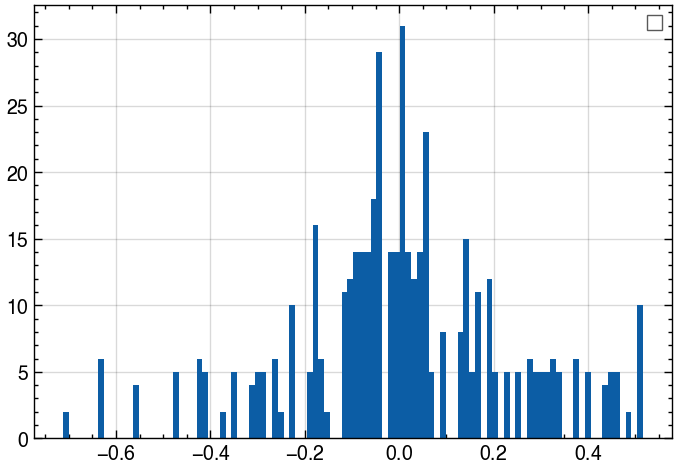

In [4]:
def print_simple_diatomic_formulae(orders_J, order_J_v_corr, orders_v, coeffs=None):
    """Energy calculations take the following form for simple diatomic molecules:
    E_vib = w_e * (v + 1/2) - omega_e_x_e * (v + 1/2)^2
    E_rot = B * (J * (J + 1))
          + D * (J * (J + 1))^2
          ...
    where the coefficients B, D, ... are a function of v as follows:
    B = B_e - alpha_e * (v + 1/2) - gamma_e * (v + 1/2)^2

    We generalize these calculations:
    E_vib = P(v+1/2) of order `orders_v` (excl. 0)
    E_rot = P(J * (J+1)) of order `orders_J` (excl. 0)
    B(v)  = P(v+1/2) of order `order_J_v_corr` (incl. 0)

    The polynomial coefficients corresponding to this form are calculated by least squares fitting:
    E=Ax
    where E is the energy, A is the matrix of coefficients, and x is the vector of the independent variable.
    """

    E_vib_components = []
    for i in range(1, orders_v + 1):
        c = coeffs[i] if coeffs is not None else f"c_v_{i}"
        E_vib_components.append(f"(-1) ** ({i+1}) * {c} * (v + 1/2)**{i}")
    E_vib_total = " \\\n\t+ ".join(E_vib_components)
    print(f"E_vib = {E_vib_total}")

    E_rot_components = []
    for i in range(1, orders_J + 1):
        B_components = []
        for j in range(order_J_v_corr + 1):
            ind = orders_v + 1 + (order_J_v_corr + 1) * (i - 1) + j
            c = coeffs[ind] if coeffs is not None else f"c_B_{j}"
            B_components.append(f"{c} * (v + 1/2)**{j}")
        B_total = "(\n\t\t" + " +\n\t\t".join(B_components) + "\n\t)"
        E_rot_components.append(f"{B_total} * (J * (J + 1))**{i}")

    if coeffs is not None:
        assert ind == len(coeffs) - 1
    E_rot_total = " \\\n\t+".join(E_rot_components)
    print(f"E_rot = {E_rot_total}")


def get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v):
    """Energy calculations take the following form for simple diatomic molecules:
    E_vib = w_e * (v + 1/2) - omega_e_x_e * (v + 1/2)^2
    E_rot = B * (J * (J + 1))
          + D * (J * (J + 1))^2
          ...
    where the coefficients B, D, ... are a function of v as follows:
    B = B_e - alpha_e * (v + 1/2) - gamma_e * (v + 1/2)^2

    We generalize these calculations:
    E_vib = P(v+1/2) of order `orders_v` (excl. 0)
    E_rot = P(J * (J+1)) of order `orders_J` (excl. 0)
    B(v)  = P(v+1/2) of order `order_J_v_corr` (incl. 0)

    The polynomial coefficients corresponding to this form are calculated by least squares fitting:
    E=Ax
    where E is the energy, A is the matrix of coefficients, and x is the vector of the independent variable.
    """
    A = [np.ones_like(v)]

    for i in range(1, orders_v + 1):
        A.append((-1) ** (i + 1) * (v + 1 / 2) ** i)

    for i in range(1, orders_J + 1):
        J_pol = (J * (J + 1)) ** i
        for j in range(order_J_v_corr + 1):
            A.append((v + 1 / 2) ** j * J_pol)

    return np.array(A).T


def fit_coefficients(J, v, E, orders_J, order_J_v_corr, orders_v):
    A = get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v)
    return np.linalg.lstsq(A, E, rcond=None)[0]


orders = [4, 4, 3]
print_simple_diatomic_formulae(*orders)
coeff = fit_coefficients(state_initial.J, state_initial.v, E_hitran, *orders)
print(coeff)

print_simple_diatomic_formulae(*orders, coeff)
E_calc = np.matmul(
    get_simple_diatomic_coeff(state_initial.J, state_initial.v, *orders), coeff
)
dE = E_hitran - E_calc

dE_std = np.std(dE)
dE_max = np.max(np.abs(dE))

print(f"Standard deviation: {dE_std:.1f} cm^-1")
print(f"Maximum deviation: {dE_max:1f} cm^-1")

plt.figure()
plt.hist(E_hitran - E_calc, bins=100)
plt.legend()
plt.show()

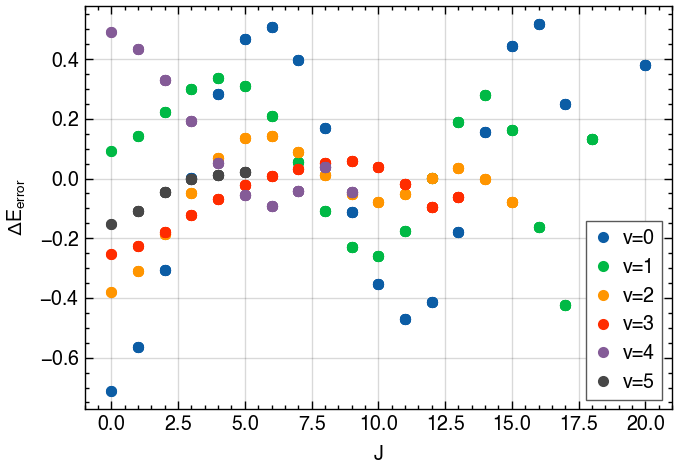

In [5]:
plt.figure()

for vi in np.unique(state_initial.v):
    idx_v = state_initial.v == vi
    plt.plot(
        state_initial.J[idx_v], dE[idx_v], label=f"v={vi}", marker="o", linestyle="None"
    )

plt.legend()
plt.xlabel("J")
plt.ylabel(r"$\Delta E_{error}$")
plt.show()